# Lab 15

By Niksh Hiremath (U20240158)

## 1. Code

### Importing libraries

In [1]:
import os
from numpy import mean, std, dstack
from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input
from keras.utils import to_categorical
from matplotlib import pyplot

### Loading the dataset

In [2]:
def load_group(filenames, prefix):
    loaded = [
        read_csv(os.path.join(prefix, fname), header=None, sep=r"\s+").values.astype(
            "float32"
        )
        for fname in filenames
    ]
    return dstack(loaded)


def load_dataset_group(group):
    prefix = os.path.join("UCI HAR Dataset", group, "Inertial Signals")
    filenames = [
        f"total_acc_x_{group}.txt",
        f"total_acc_y_{group}.txt",
        f"total_acc_z_{group}.txt",
        f"body_acc_x_{group}.txt",
        f"body_acc_y_{group}.txt",
        f"body_acc_z_{group}.txt",
        f"body_gyro_x_{group}.txt",
        f"body_gyro_y_{group}.txt",
        f"body_gyro_z_{group}.txt",
    ]
    X = load_group(filenames, prefix)
    y = read_csv(
        os.path.join("UCI HAR Dataset", group, f"y_{group}.txt"),
        header=None,
        sep=r"\s+",
    ).values.astype("float32")
    return X, y

In [3]:
X_train, y_train = load_dataset_group("train")
X_test, y_test = load_dataset_group("test")

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7352, 128, 9), (2947, 128, 9), (7352, 1), (2947, 1))

### Loading and encoding target labels

In [4]:
y_train = to_categorical(y_train - 1, num_classes=6)
y_test = to_categorical(y_test - 1, num_classes=6)

print(f"y_train shape after encoding: {y_train.shape}")
print(f"y_test shape after encoding: {y_test.shape}")

y_train shape after encoding: (7352, 6)
y_test shape after encoding: (2947, 6)


### Defining and evaluating the LSTM model

In [5]:
N_TIMESTEPS = X_train.shape[1]
N_FEATURES = X_train.shape[2]
N_OUTPUTS = y_train.shape[1]
N_EPOCHS = 15
BATCH_SIZE = 64
N_RUNS = 10

ACTIVITY_LABELS = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying",
]

In [6]:
def build_lstm_model(n_timesteps, n_features, n_outputs):
    # Single LSTM hidden layer followed by dropout, dense, and output layer
    model = Sequential(
        [
            Input(shape=(n_timesteps, n_features)),
            LSTM(100),
            Dropout(0.5),
            Dense(100, activation="relu"),
            Dense(n_outputs, activation="softmax"),
        ]
    )
    model.compile(
        loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
    )
    return model

In [7]:
def evaluate_model(X_train, y_train, X_test, y_test):
    model = build_lstm_model(N_TIMESTEPS, N_FEATURES, N_OUTPUTS)
    model.fit(X_train, y_train, epochs=N_EPOCHS, batch_size=BATCH_SIZE)
    _, accuracy = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE)
    return accuracy

### Running 10 evaluations

In [8]:
scores = []

for run in range(1, N_RUNS + 1):
    acc = evaluate_model(X_train, y_train, X_test, y_test)
    scores.append(acc)
    print(f"Run {run:>2}/{N_RUNS}: Accuracy: {acc * 100:.2f}%")

print(f"\nMean Accuracy: {mean(scores) * 100:.2f}%")
print(f"Std Deviation: {std(scores) * 100:.2f}%")

Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.4927 - loss: 1.1939
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.6469 - loss: 0.8306
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.7331 - loss: 0.6485
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.8098 - loss: 0.5008
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.8832 - loss: 0.3342
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9195 - loss: 0.2277
Epoch 7/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9195 - loss: 0.2400
Epoch 8/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9355 - loss: 0.1841
Epoch 9/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9388 - loss: 0.1630
Epoch 10/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9442 - loss: 0.1448
Epoch 11/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9391 - loss: 0.1468
Epoch 12/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 

### Plotting accuracy across runs

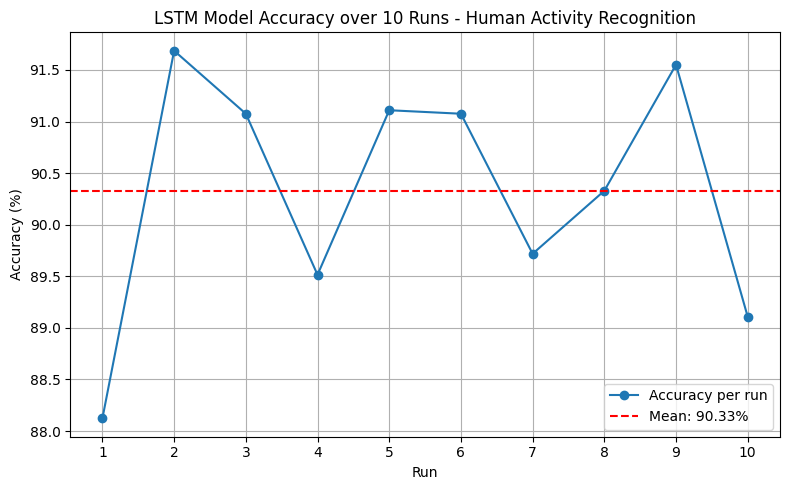

In [9]:
pyplot.figure(figsize=(8, 5))
pyplot.plot(
    range(1, N_RUNS + 1),
    [s * 100 for s in scores],
    marker="o",
    label="Accuracy per run",
)
pyplot.axhline(
    y=mean(scores) * 100,
    color="red",
    linestyle="--",
    label=f"Mean: {mean(scores)*100:.2f}%",
)

pyplot.xlabel("Run")
pyplot.ylabel("Accuracy (%)")
pyplot.title("LSTM Model Accuracy over 10 Runs - Human Activity Recognition")
pyplot.xticks(range(1, N_RUNS + 1))
pyplot.legend()
pyplot.grid()
pyplot.tight_layout()
pyplot.show()

---

## 2. Report

---

### Q1: Why was this problem suitable for LSTM and not just any other machine learning algorithm?

**Ans:**

- Human activity recognition involves time series data.

- Traditional ML algorithms like SVM treat each sample independently and have no mechanism to capture temporal dependencies across time steps.

- LSTMs are specifically designed to model sequential data by maintaining a hidden state that carries information from previous time steps, making them well suited to learn patterns like the rhythm of walking or the stillness of sitting.

---

### Q2: Is a many-to-many model a more real-world scenario for this problem or a many-to-one model and why?

**Ans:**

- A many-to-one model takes a fixed window of 128 time steps and produces a single activity label. 

- A many-to-many model would produce a label at every time step, which is more representative of real world deployment where the system must continuously classify activity as new sensor data streams in.

---

### Q3: Explain the meaning of "Short Memory" and "Long Memory" in context of LSTMs.

**Ans:**

- **Short Memory** refers to the hidden state ($h_t$) in an LSTM, which carries information from the immediately preceding time step. It represents the most recent context and is reset or updated at every step, so it reflects short term patterns.

- **Long Memory** refers to the cell state ($c_t$), which flows through time with only minor linear modifications controlled by the forget and input gates. It can carry relevant information across many time steps without it decaying, enabling the network to remember long range dependencies.

---

### Q4: What are the three parts of an LSTM node and their functions?

**Ans:**

- **Forget Gate:** Decides what information from the previous cell state should be discarded.

- **Input Gate:** Decides what new information should be written into the cell state.

- **Output Gate:** Decides what part of the cell state to expose as the hidden state output.

---

### Q5: What problems do RNNs face that LSTMs are able to adapt to fix?

**Ans:**

- **Vanishing gradient problem:** In standard RNNs, gradients are backpropagated through many time steps and shrink exponentially, making it impossible to learn long range dependencies. LSTM solves this by using the cell state with additive updates.

- **Short term memory:** Standard RNNs tend to forget information from distant past steps because new inputs constantly overwrite the hidden state. LSTMs explicitly maintain a separate cell state.

- **Exploding gradients:** While LSTMs do not directly solve this, the gating structure reduces the severity of gradient explosions compared to vanilla RNNs.

---